In [24]:
import numpy as np
import matplotlib.pyplot as plt
from dmrg.MPS import MPS 
from dmrg.cont import CONT
import os
from dmrg.dmrg import dmrg

class MPO_main():
    
    Id = np.identity(2)
    X = np.array([[0, 1], [1, 0]])
    Y = np.array([[0, 0-1j], [0+1j, 0]])
    Z = np.array([[1, 0], [0, -1]])
    
    def __init__(self, h, k, J, pol=None, d=2):
        self.h = h
        self.k = k
        self.J = J

        self.pol = pol
        self.d = d

    def Wl(self):
        Wleft = np.zeros((2, 2, 9),dtype='complex')
        Wleft[:, :, 0] = MPO_main.Id
        Wleft[:, :, 1] = MPO_main.X
        Wleft[:, :, 2] = MPO_main.Y
        Wleft[:, :, 3] = MPO_main.Z
        Wleft[:, :, 8] = self.h * MPO_main.Z

        if self.pol == 'tot':
            Wleft[:,:,8] += 25*MPO_main.X

        return Wleft
    
    def Wr(self):
        Wright = np.zeros((2, 2, 9),dtype='complex')
        Wright[:, :, 0] =  self.h * MPO_main.Z
        Wright[:, :, 1] =  self.J * MPO_main.X
        Wright[:, :, 4] =  self.k * MPO_main.Y
        Wright[:, :, 5] = -self.k * MPO_main.X
        Wright[:, :, 6] =  self.k * MPO_main.Z
        Wright[:, :, 7] = -self.k * MPO_main.X
        Wright[:, :, 8] =  MPO_main.Id

        if self.pol == 'tot':
            Wright[:,:,0] -= 25*MPO_main.X

        return Wright
    
    def mpo(self, p=None):
        MPO = np.zeros((2, 2, 9, 9),dtype='complex')

        # All interactions
        MPO[:,:,0, 0] =  MPO_main.Id
        MPO[:,:,0, 1] =  MPO_main.X
        MPO[:,:,0, 2] =  MPO_main.Y
        MPO[:,:,0, 3] =  MPO_main.Z
        MPO[:,:,0, 8] =  self.h * MPO_main.Z

        MPO[:,:,1, 4] =  MPO_main.Id
        MPO[:,:,1, 6] =  MPO_main.Y
        MPO[:,:,2, 5] =  MPO_main.Id
        MPO[:,:,3, 7] =  MPO_main.Y

        MPO[:,:,1, 8] =  self.J * MPO_main.X
        MPO[:,:,4, 8] =  self.k * MPO_main.Y
        MPO[:,:,5, 8] = -self.k * MPO_main.X
        MPO[:,:,6, 8] =  self.k * MPO_main.Z
        MPO[:,:,7, 8] = -self.k * MPO_main.X 
        MPO[:,:,8, 8] =  MPO_main.Id

        return MPO

In [18]:
L = 20 
mps = MPS(L)
h = MPO_main(h=1,k=0.5,J=1,pol='tot')
cont = CONT(mps=mps,H=h)
sys = dmrg(cont=cont,chi=100,cut=1e-12)

sys.chi = 4
En = sys.infinite()
sys.chi = 100
E_sweep = []

for site,dir in mps.first_sweep():
    E,S, _ = sys.step2sites(site,dir=dir)
    E_sweep.append(E)

k = 0 
En_temp = np.zeros(2*L-8)
En_temp[0] = E

while np.abs(En_temp[0] - En_temp[-1]) > 1e-10:
    j = 0
    for site,dir in mps.sweep():
        E,S, _ = sys.step2sites(site,dir=dir)
        En_temp[j] = E
        E_sweep.append(E)
        j +=1

    if k > 5:
        break
    
    k += 1

/tmp/ipykernel_5357/351502787.py:3: RuntimeWarning: divide by zero encountered in log
  ax.plot(np.log(E_sweep - E_sweep[-1]), '.--')
/tmp/ipykernel_5357/351502787.py:3: RuntimeWarning: invalid value encountered in log
  ax.plot(np.log(E_sweep - E_sweep[-1]), '.--')


Text(0.5, 1.0, 'Energy convergence')

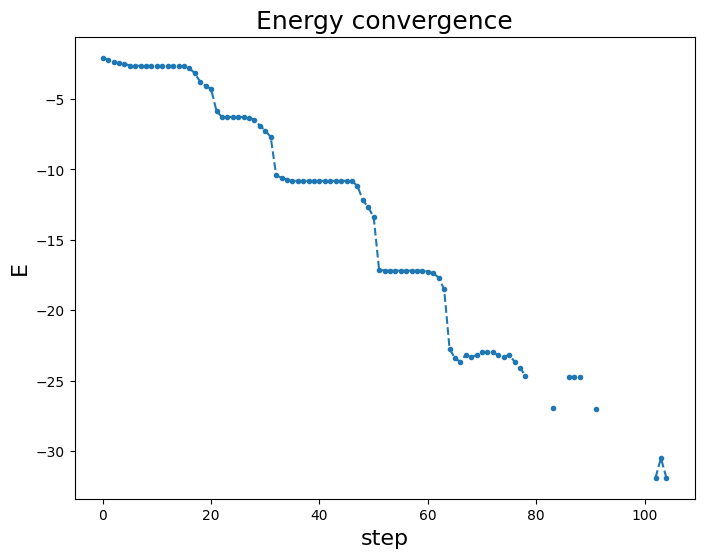

In [20]:
fig,ax = plt.subplots(figsize=(8,6))
# ax.plot(E_sweep,'.--')
ax.plot(np.log(E_sweep - E_sweep[-1]), '.--')

ax.set_xlabel('step',fontsize=16)
ax.set_ylabel('E',fontsize=16)
ax.set_title('Energy convergence',fontsize=18)

In [25]:
# import the observables class
from dmrg.obs import observables

# define observables
obs = observables(mps)

path_par = os.getcwd()
for site,dir in mps.right_sweep():
    En,S,_ = sys.step2sites(site,dir=dir,stage='Final')

    # Store local magnetization
    with open(path_par + 'X.txt','a') as fz:
            fz.write(f'{site} {obs.single_site(site,h.X).real} \n')
    with open(path_par + 'Y.txt', 'a') as fz:
            fz.write(f'{site} {obs.single_site(site,h.Y).real} \n')
    with open(path_par + 'Z.txt', 'a') as fz:
            fz.write(f'{site} {obs.single_site(site,h.Z).real} \n')

    # Store entanglement entropy
    with open(path_par + 'S.txt','a') as fz:
            fz.write(f'{site} {site+1} {S} \n')

    # Store all two point correlations from site
    obs.all_corr(path_par + 'XX.txt', site, string=h.Id , obs1=h.X)
    obs.all_corr(path_par + 'YY.txt', site, string=h.Id , obs1=h.Y)
    obs.all_corr(path_par + 'ZZ.txt', site, string=h.Id , obs1=h.Z)

    obs.all_corr(path_par + 'XZ.txt', site, string=h.Id , obs1=h.X, obs2=h.Z)
    obs.all_corr(path_par + 'XY.txt', site, string=h.Id , obs1=h.X, obs2=h.Y)
    obs.all_corr(path_par + 'YZ.txt', site, string=h.Id , obs1=h.Y, obs2=h.Z)

    obs.all_corr(path_par + 'XYZ.txt',site, string=h.Y, obs1=h.X, obs2=h.Z)

ValueError: cannot reshape array of size 192 into shape (4,2,2,13)